# DBSCAN Clustering on Make Moons Dataset

First, let's import the necessary libraries and generate the `make_moons` dataset.

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Generate the make_moons dataset
X, y = make_moons(n_samples=200, noise=0.05, random_state=42)

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (200, 2)
Shape of y: (200,)


Now, let's visualize the generated dataset to see its structure.

/tmp/ipykernel_3505/3391694131.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=50, edgecolors='k', cmap='viridis')


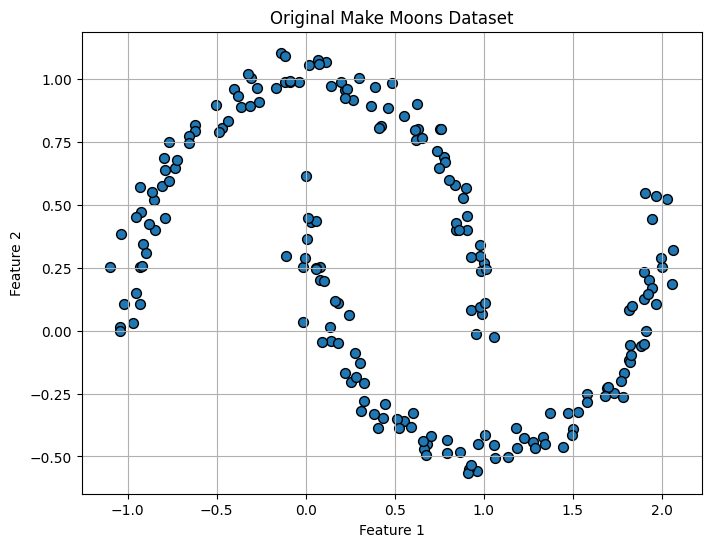

In [2]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, edgecolors='k', cmap='viridis')
plt.title('Original Make Moons Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

Next, we will apply DBSCAN clustering with `epsilon=0.1` and `min_samples=10`.

In [7]:
from sklearn.cluster import DBSCAN

# Initialize DBSCAN with specified parameters
dbsc = DBSCAN(eps=0.3, min_samples=10)

# Fit DBSCAN to the data and predict clusters
clusters = dbsc.fit_predict(X)

# Print the cluster labels (noisy samples are labeled as -1)
print(f"Cluster labels: {clusters}")
print(f"Number of unique clusters found: {len(set(clusters)) - (1 if -1 in clusters else 0)}")
print(f"Number of noise points: {list(clusters).count(-1)}")

Cluster labels: [0 0 0 1 1 1 0 1 1 0 0 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1
 1 1 0 0 1 0 0 1 1 0 0 1 0 1 1 0 1 1 0 1 0 1 0 1 0 0 0 0 1 0 1 0 1 0 1 1 0
 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 1 0 0 1 0 0 1 1 1 1 0 0 1 1 1
 0 1 1 0 1 0 0 1 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 1 1 1 1 0 0 0 0 1
 0 0 1 1 0 0 0 0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 1 0 0 1 1 1
 1 0 1 0 0 1 1 0 1 0 1 0 0 1 1]
Number of unique clusters found: 2
Number of noise points: 0


Finally, let's visualize the results of the DBSCAN clustering.

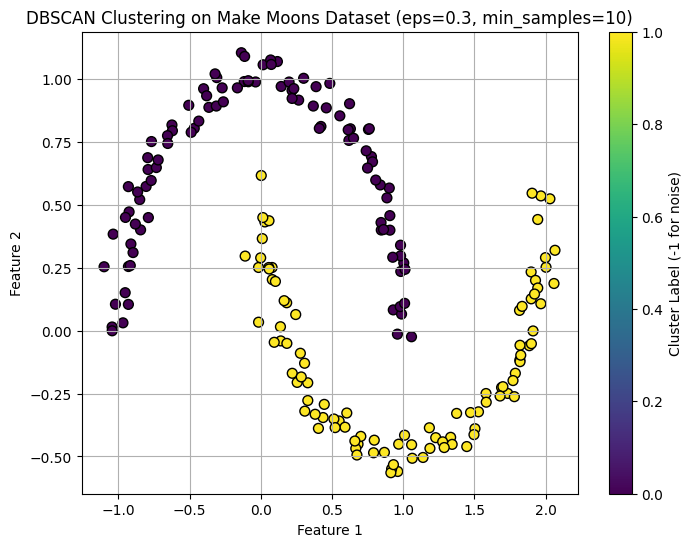

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=50, edgecolors='k', cmap='viridis')
plt.title(f'DBSCAN Clustering on Make Moons Dataset (eps={dbsc.eps}, min_samples=10)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label (-1 for noise)')
plt.grid(True)
plt.show()

## K-Nearest Neighbors (KNN) Classification

KNN is a classification algorithm that can be used to categorize data points based on the majority class of their nearest neighbors. We'll split our `make_moons` data into training and testing sets, train a KNN classifier, and then visualize its predictions.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Train set shape: {X_train.shape}, {y_train.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Train set shape: (140, 2), (140,)
Test set shape: (60, 2), (60,)


In [10]:
# Initialize and train a KNeighborsClassifier
# We'll choose a reasonable number of neighbors, for example, 5.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Classifier Accuracy: {accuracy:.4f}")

KNN Classifier Accuracy: 1.0000


Let's visualize the decision boundary of the KNN classifier on the entire dataset to see how it separates the 'moons'.

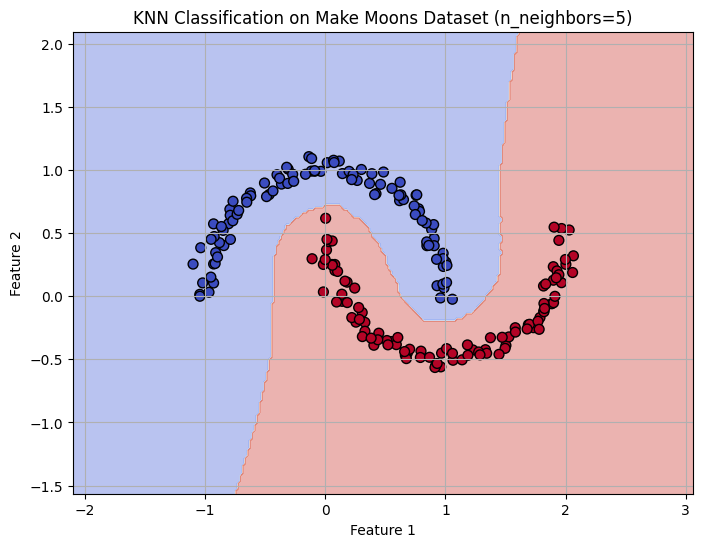

In [11]:
import numpy as np

plt.figure(figsize=(8, 6))

# Create a mesh to plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict class for each point in the mesh
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')

# Plot the original data points
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolors='k', cmap='coolwarm')

plt.title('KNN Classification on Make Moons Dataset (n_neighbors=5)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()